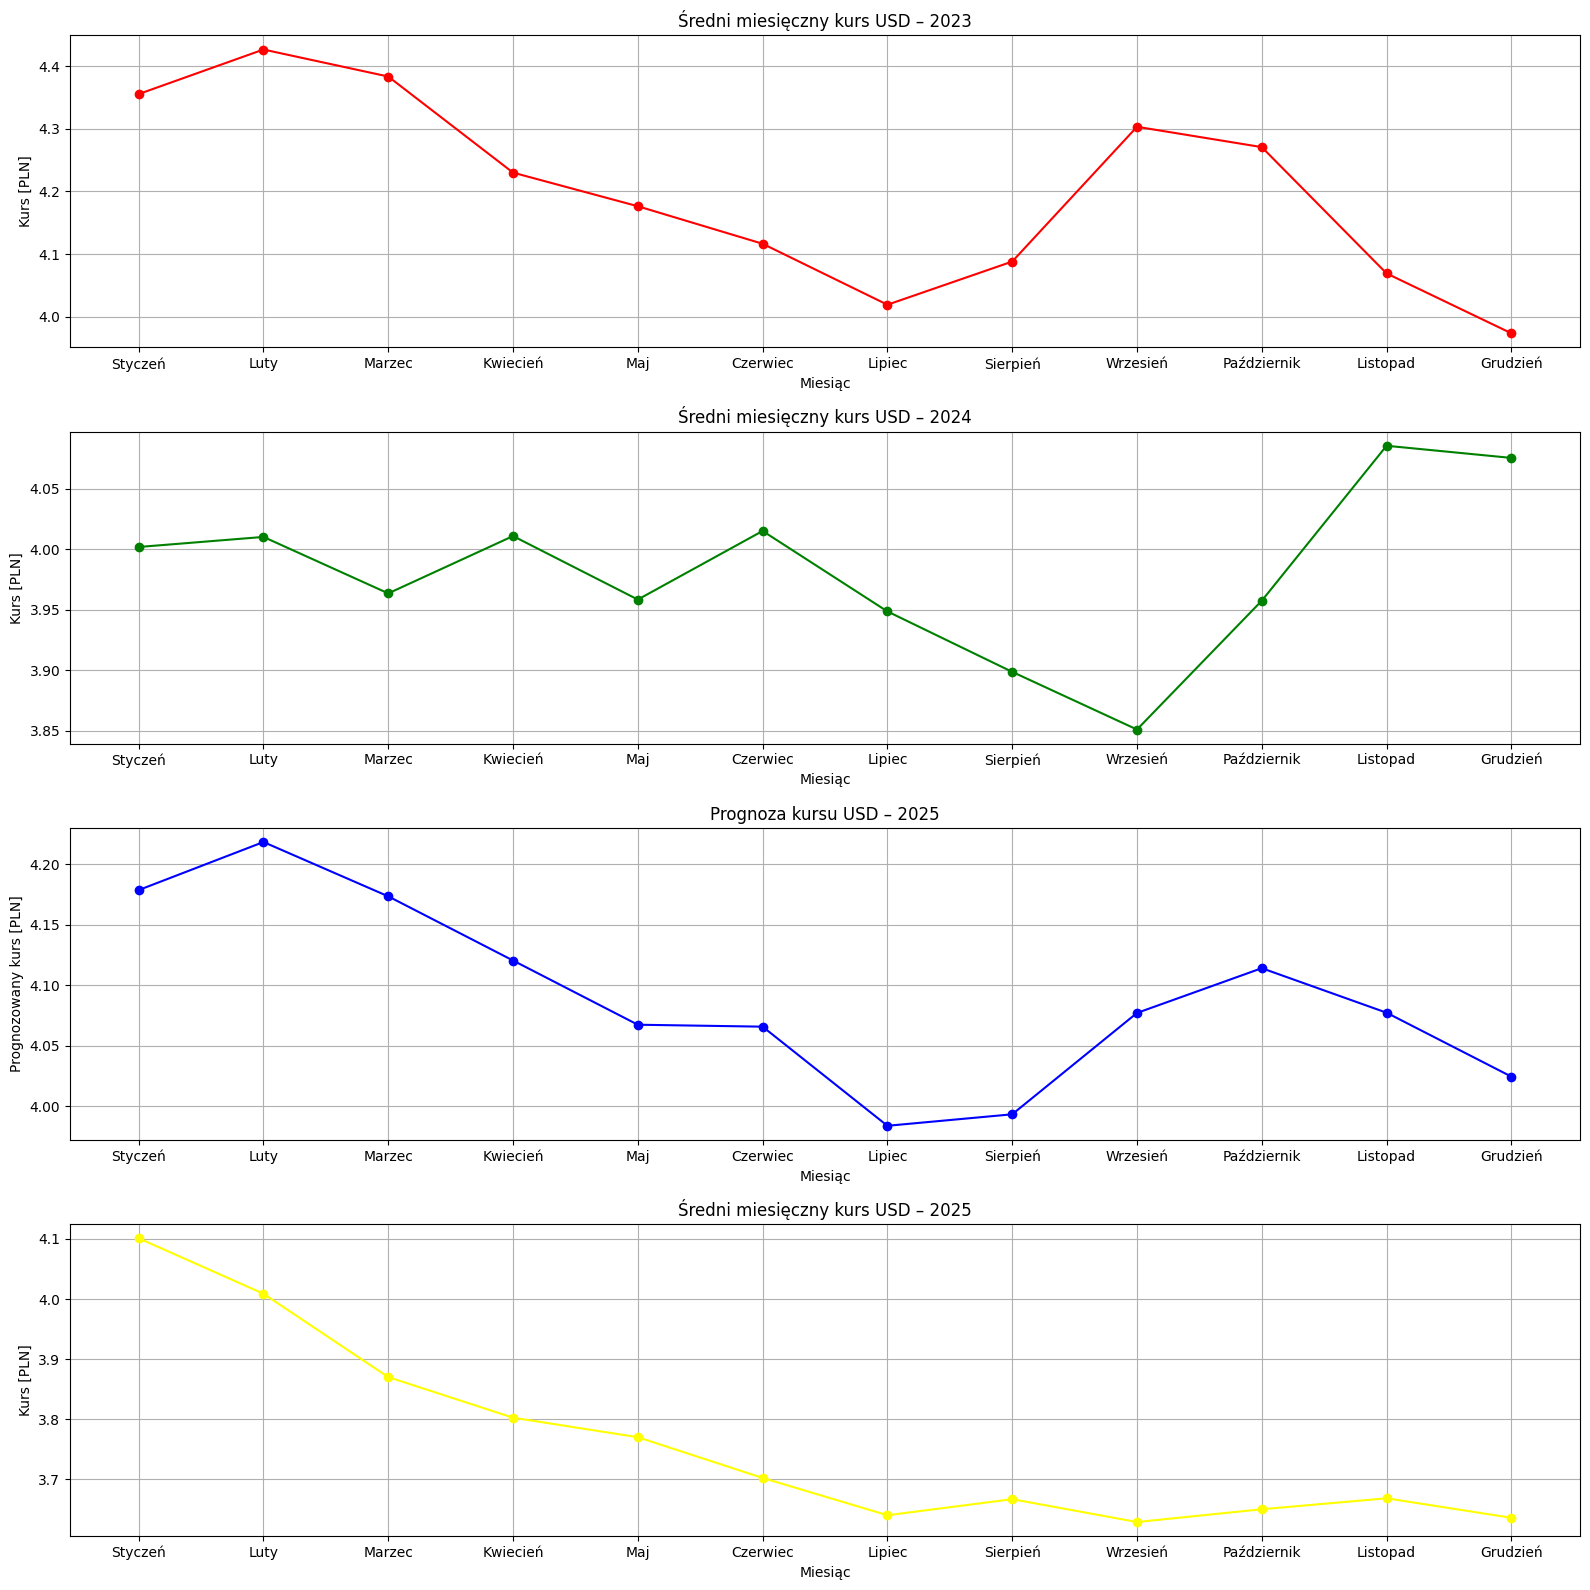

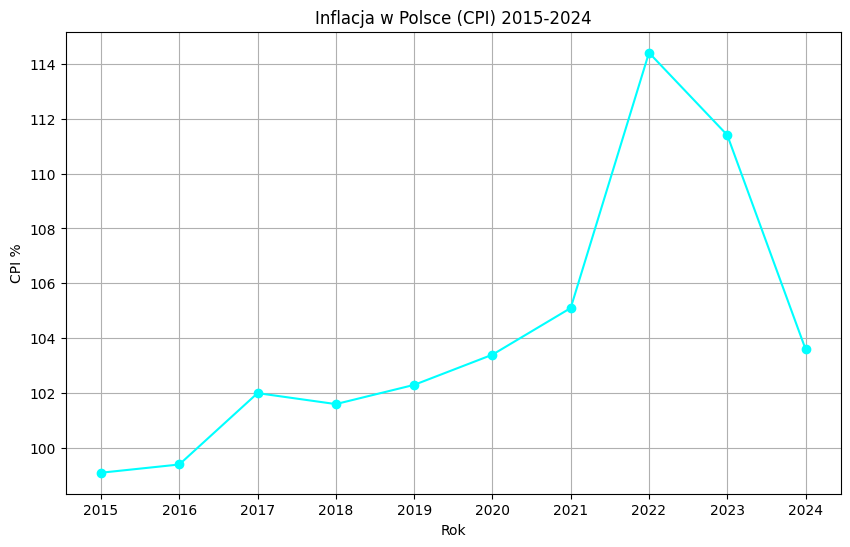

In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import json

def kurs_usd(rok):
    url = f"https://api.nbp.pl/api/exchangerates/rates/A/USD/{rok}-01-01/{rok}-12-31/?format=json"
    url2025 = "https://api.nbp.pl/api/exchangerates/rates/A/USD/2025-01-01/2025-12-04/?format=json"
    if rok == 2025: url = url2025

    r = requests.get(url)
    dane = r.json()['rates']
    
    dane = pd.DataFrame({
        "data": [x['effectiveDate'] for x in dane],
        "kurs": [x['mid'] for x in dane]
    })
    #print(dane[:3])
    dane["data"] = pd.to_datetime(dane["data"])
    dane["miesiac"] = dane["data"].dt.month
    return dane

def inflacja_dane(rok):
    # https://api.stat.gov.pl/Home/BdlApi info o api
    # 217230 ID CPI wskazniku inflacji
    url = f"https://bdl.stat.gov.pl/api/v1/data/by-variable/217230?format=json&year={rok}"
    r = requests.get(url)
    dane = r.json()['results']
    #print(json.dumps(dane, indent=4))
    val = dane[0]['values'][0]['val']
    return val

rok1 = 2023
rok2 = 2024
rok3 = 2025

dane1 = kurs_usd(rok1)
dane2 = kurs_usd(rok2)
dane3 = kurs_usd(rok3)

#print("d1 :", dane1[:3])

mies1 = dane1.groupby("miesiac")["kurs"].mean()
mies2 = dane2.groupby("miesiac")["kurs"].mean()
mies3 = dane3.groupby("miesiac")["kurs"].mean()

#print("mies1 :", mies1[:3])
predykcja = []

for m in range(1, 13):
    sr = (mies1[m] + mies2[m]) / 2
    predykcja.append(sr)

miesiace = ["Styczeń","Luty","Marzec","Kwiecień","Maj","Czerwiec","Lipiec","Sierpień","Wrzesień","Październik","Listopad","Grudzień"]
plt.figure(figsize=(16, 16))

# rok 2023
plt.subplot(4, 1, 1)
plt.plot(mies1.index, mies1.values, marker="o", color="red")
plt.xticks(range(1, 13), miesiace)
plt.title(f"Średni miesięczny kurs USD – {rok1}")
plt.xlabel("Miesiąc")
plt.ylabel("Kurs [PLN]")
plt.grid(True)

# rok 2024
plt.subplot(4, 1, 2)
plt.plot(mies2.index, mies2.values, marker="o", color="green")
plt.xticks(range(1, 13), miesiace)
plt.title(f"Średni miesięczny kurs USD – {rok2}")
plt.xlabel("Miesiąc")
plt.ylabel("Kurs [PLN]")
plt.grid(True)

# prognoza 2025
plt.subplot(4, 1, 3)
plt.plot(range(1, 13), predykcja, marker="o", color="blue")
plt.xticks(range(1, 13), miesiace)
plt.title(f"Prognoza kursu USD – {rok3}")
plt.xlabel("Miesiąc")
plt.ylabel("Prognozowany kurs [PLN]")
plt.grid(True)

# rzeczywiste 2025
plt.subplot(4, 1, 4)
plt.plot(mies3.index, mies3.values, marker="o", color="yellow")
plt.xticks(range(1, 13), miesiace)
plt.title(f"Średni miesięczny kurs USD – {rok3}")
plt.xlabel("Miesiąc")
plt.ylabel("Kurs [PLN]")
plt.grid(True)

plt.tight_layout()
plt.show()

lata = range(2015, 2025)
cpi = [inflacja_dane(i) for i in lata]

plt.figure(figsize=(10,6))
plt.plot(lata, cpi, marker='o', color='cyan')
plt.xticks(lata)
plt.title("Inflacja w Polsce (CPI) 2015-2024")
plt.xlabel("Rok")
plt.ylabel("CPI %")
plt.grid(True)

plt.show()
